# Cross-Crop Endogenous Correlation Blocks

This notebook draws correlation heatmaps where each crop is used as a reference block. For example, for wheat it correlates `corn_{weekly,monthly,seasonal}_rv` and `soybeans_{weekly,monthly,seasonal}_rv` against all wheat endogenous features. The same pattern is repeated for corn and soybeans.

In [20]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.util.path import DATA_DIR

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

In [21]:
# Configure the dataset and crop order.
DATA_PATH = DATA_DIR / 'ag' / 'v6.csv'
CROPS = ('wheat', 'corn', 'soybeans')
TARGET_SUFFIXES = ('weekly_rv', 'monthly_rv', 'seasonal_rv')
METHOD = 'pearson'
DROP_MISSING = True

In [22]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(832, 93)


,date,corn_weekly_rv,corn_weekly_rvg,corn_weekly_rvb,corn_weekly_rsk,corn_weekly_rku,corn_weekly_jumps,corn_weekly_tru,corn_weekly_trd,corn_weekly_lev,...,ssta_lanina,SOI_index,NAO_index,DJIA_Index,WTI_Index,Broad_Dollar_index,Text_Climate_Anomaly,Stock_Uncertainty,frbsf_sentiment,epu_index
0,2009-04-13,0.014740,0.009140,0.011311,-1.059369,12.520426,0.000039,0.000065,0.000103,-0.212748,...,0.0,0.530000,0.364000,NaN,3.911023,100.1369,-0.022368,170.870000,-0.225714,117.434286
1,2009-04-20,0.015534,0.010501,0.011049,-0.119789,12.957318,0.000047,0.000102,0.000097,-0.087395,...,0.0,0.320000,0.802667,8.996688,3.818152,101.4480,0.186285,51.764286,-0.235714,127.531429
2,2009-04-27,0.020031,0.014932,0.013110,0.887230,12.171946,0.000088,0.000187,0.000121,0.129211,...,0.0,0.110000,1.241333,9.013402,3.914221,100.7258,0.615175,58.567143,-0.255714,170.924286
3,2009-05-04,0.019517,0.015243,0.011858,1.633651,17.233828,0.000054,0.000198,0.000107,0.228647,...,0.0,-0.068756,1.546378,9.056565,3.998384,99.1340,0.257109,57.110000,-0.237143,143.804286
4,2009-05-11,0.016296,0.010815,0.011872,-0.590406,13.131681,0.000023,0.000080,0.000136,-0.057299,...,0.0,-0.054839,1.027419,9.020225,4.062682,97.7470,0.107827,28.824286,-0.248571,117.497143


In [23]:
def endogenous_columns(frame: pd.DataFrame, crop: str) -> list[str]:
    prefix = f'{crop}_'
    return [column for column in frame.columns if column.startswith(prefix)]


def core_rv_columns(frame: pd.DataFrame, crop: str, suffixes: tuple[str, ...]) -> list[str]:
    selected = []
    for suffix in suffixes:
        column = f'{crop}_{suffix}'
        if column in frame.columns:
            selected.append(column)
    return selected


crop_feature_map = {crop: endogenous_columns(df, crop) for crop in CROPS}
crop_core_map = {crop: core_rv_columns(df, crop, TARGET_SUFFIXES) for crop in CROPS}

for crop in CROPS:
    print(f'{crop}: {len(crop_feature_map[crop])} endogenous features, core RV columns = {crop_core_map[crop]}')

wheat: 27 endogenous features, core RV columns = ['wheat_weekly_rv', 'wheat_monthly_rv', 'wheat_seasonal_rv']
corn: 27 endogenous features, core RV columns = ['corn_weekly_rv', 'corn_monthly_rv', 'corn_seasonal_rv']
soybeans: 27 endogenous features, core RV columns = ['soybeans_weekly_rv', 'soybeans_monthly_rv', 'soybeans_seasonal_rv']


In [24]:
selected_columns = sorted({column for columns in crop_feature_map.values() for column in columns})
work_df = df[selected_columns].copy()
work_df = work_df.apply(pd.to_numeric, errors='coerce')

if DROP_MISSING:
    work_df = work_df.dropna()
else:
    work_df = work_df.fillna(work_df.mean(numeric_only=True))

corr = work_df.corr(method=METHOD)
corr.head()

,corn_monthly_jumps,corn_monthly_lev,corn_monthly_rku,corn_monthly_rsk,corn_monthly_rv,corn_monthly_rvb,corn_monthly_rvg,corn_monthly_trd,corn_monthly_tru,corn_seasonal_jumps,...,wheat_seasonal_tru,wheat_weekly_jumps,wheat_weekly_lev,wheat_weekly_rku,wheat_weekly_rsk,wheat_weekly_rv,wheat_weekly_rvb,wheat_weekly_rvg,wheat_weekly_trd,wheat_weekly_tru
corn_monthly_jumps,1.000000,-0.127176,0.725046,-0.099007,0.672863,0.662037,0.641708,0.740763,0.753416,0.676079,...,0.169604,0.134113,0.072156,0.058455,0.067311,0.212290,0.195425,0.219133,0.149869,0.159776
corn_monthly_lev,-0.127176,1.000000,-0.084857,0.923499,-0.081191,-0.194409,0.040694,-0.231366,0.054277,-0.026762,...,0.063266,-0.042907,-0.044993,-0.063222,-0.038107,-0.012761,-0.000663,-0.021811,0.000996,-0.024460
corn_monthly_rku,0.725046,-0.084857,1.000000,-0.089057,0.460289,0.444847,0.431239,0.514559,0.524031,0.447050,...,0.139256,0.096595,0.031898,0.127260,0.023144,0.117511,0.109964,0.115332,0.087179,0.076940
corn_monthly_rsk,-0.099007,0.923499,-0.089057,1.000000,-0.069270,-0.194808,0.065099,-0.275328,0.132938,-0.017705,...,0.045241,-0.045592,-0.016197,-0.063208,-0.013191,-0.029138,-0.022926,-0.031090,-0.015721,-0.027031
corn_monthly_rv,0.672863,-0.081191,0.460289,-0.069270,1.000000,0.989666,0.988447,0.918825,0.918447,0.649287,...,0.520001,0.313053,0.014202,0.029765,0.021703,0.541518,0.529149,0.529055,0.393260,0.371459


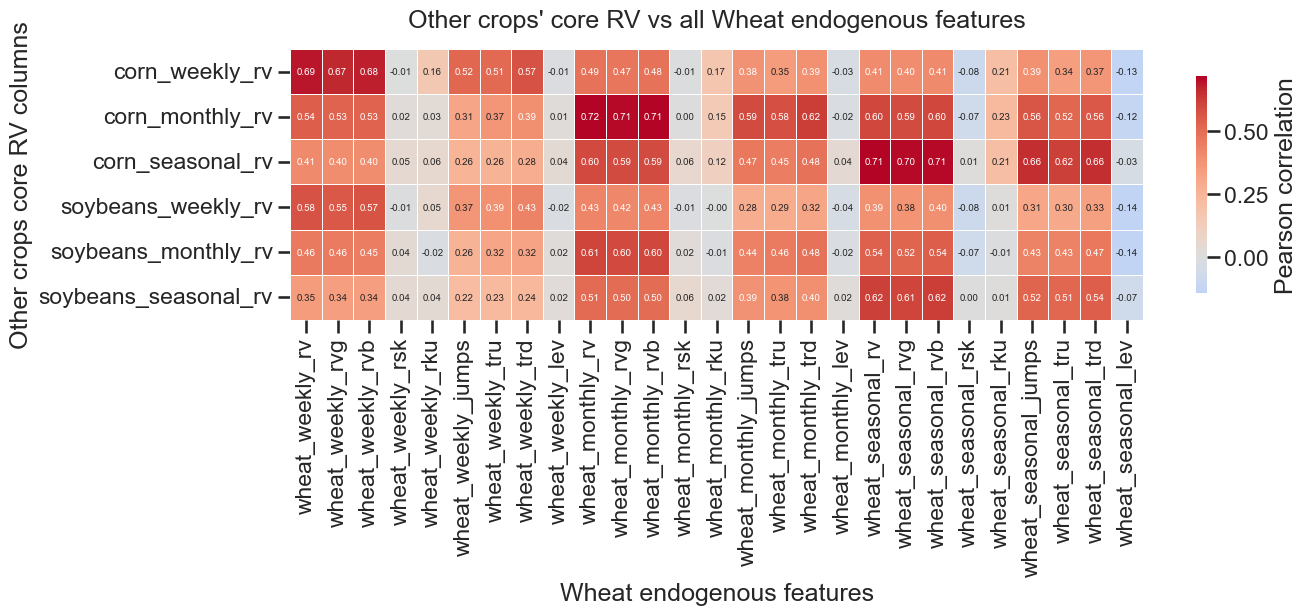

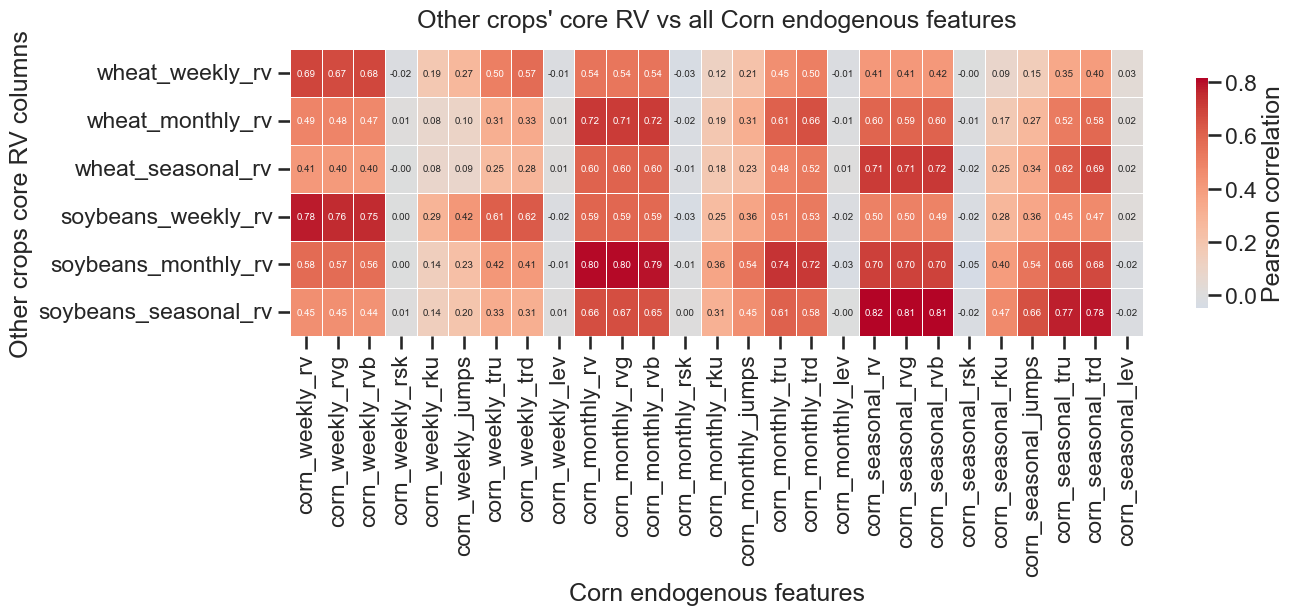

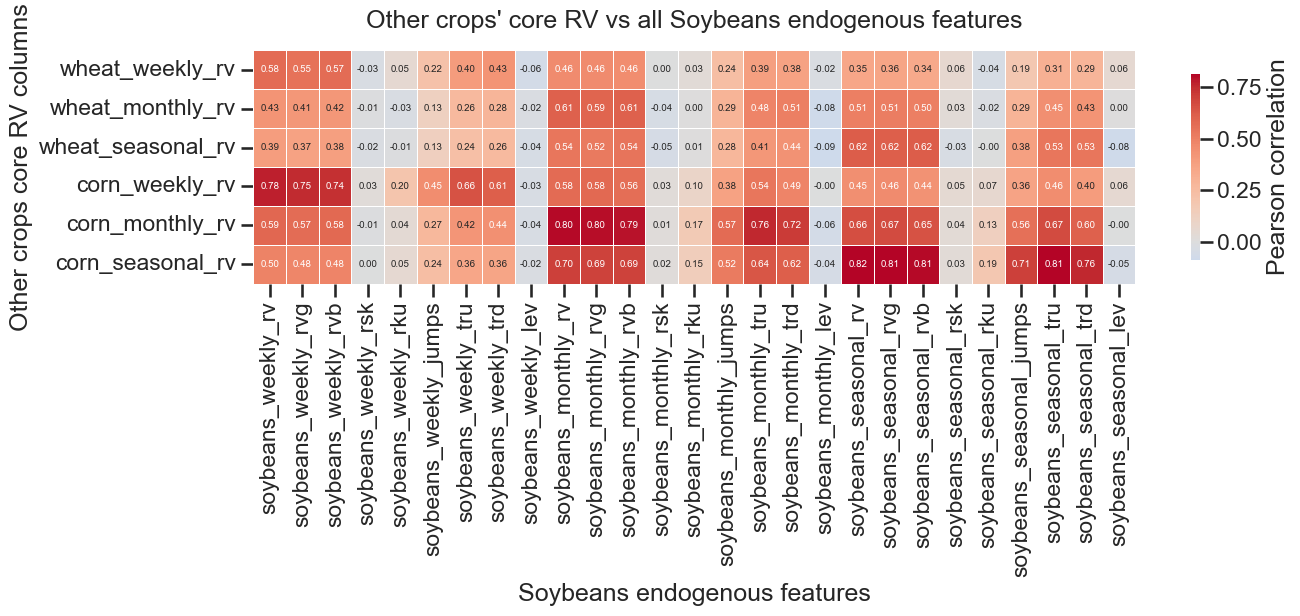

In [26]:
for reference_crop in CROPS:
    reference_features = crop_feature_map[reference_crop]
    other_core_rows = []
    for other_crop in CROPS:
        if other_crop == reference_crop:
            continue
        other_core_rows.extend(crop_core_map[other_crop])
    block = corr.loc[other_core_rows, reference_features]
    fig_width = max(14, 0.32 * len(reference_features) + 4)
    fig_height = max(5, 0.75 * len(other_core_rows) + 2)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(
        block,
        cmap='coolwarm',
        center=0,
        linewidths=0.5,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 7},
        cbar_kws={'shrink': 0.8, 'label': f'{METHOD.title()} correlation'},
        ax=ax,
    )
    ax.set_title(
        f"Other crops' core RV vs all {reference_crop.title()} endogenous features",
        pad=16,
    )
    ax.set_xlabel(f'{reference_crop.title()} endogenous features')
    ax.set_ylabel('Other crops core RV columns')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

## Notes

- For `reference_crop = 'wheat'`, rows are `corn_weekly_rv`, `corn_monthly_rv`, `corn_seasonal_rv`, `soybeans_weekly_rv`, `soybeans_monthly_rv`, and `soybeans_seasonal_rv`.
- Columns are all endogenous features of the reference crop, such as all `wheat_*` columns.
- The notebook repeats the same pattern for `corn` and `soybeans`.
- This keeps the rows limited to the three core RV horizons of the other crops, while the columns include the full endogenous block of the reference crop.